# Read the dataset

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf

df = pd.read_csv('data/jena_cleaned.csv', index_col='Date Time', parse_dates=True)

print(df.shape)
df.head()

I0000 00:00:1781185054.728459   10711 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781185054.809201   10711 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781185056.562627   10711 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


(420551, 14)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


# Select features and drop rows with NaN

In [2]:
features = ['T (degC)', 'p (mbar)', 'Tdew (degC)', 'rh (%)', 
            'VPact (mbar)', 'VPdef (mbar)', 'wv (m/s)', 'wd (deg)']

df = df[features]

df = df.dropna()

print(f"Shape after feature selection and NaN removal: {df.shape}")

Shape after feature selection and NaN removal: (420533, 8)


# Add cyclical encoding for wind direction and time

In [3]:
df['wd_sin'] = np.sin(2 * np.pi * df['wd (deg)'] / 360)
df['wd_cos'] = np.cos(2 * np.pi * df['wd (deg)'] / 360)
df = df.drop(columns=['wd (deg)'])

df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
df['doy_sin'] = np.sin(2 * np.pi * df.index.dayofyear / 365)
df['doy_cos'] = np.cos(2 * np.pi * df.index.dayofyear / 365)

print(f"Shape after encoding: {df.shape}")
print(df.head())

Shape after encoding: (420533, 13)
                     T (degC)  p (mbar)  Tdew (degC)  rh (%)  VPact (mbar)  \
Date Time                                                                    
2009-01-01 00:10:00     -8.02    996.52        -8.90    93.3          3.11   
2009-01-01 00:20:00     -8.41    996.57        -9.28    93.4          3.02   
2009-01-01 00:30:00     -8.51    996.53        -9.31    93.9          3.01   
2009-01-01 00:40:00     -8.31    996.51        -9.07    94.2          3.07   
2009-01-01 00:50:00     -8.27    996.51        -9.04    94.1          3.08   

                     VPdef (mbar)  wv (m/s)    wd_sin    wd_cos  hour_sin  \
Date Time                                                                   
2009-01-01 00:10:00          0.22      1.03  0.464842 -0.885394       0.0   
2009-01-01 00:20:00          0.21      0.72  0.693402 -0.720551       0.0   
2009-01-01 00:30:00          0.20      0.19  0.146083 -0.989272       0.0   
2009-01-01 00:40:00          0.19

# Split the dataset into train/test/val chronologically

In [4]:
n = len(df)

train_size = int(n * 0.70) 
val_size   = int(n * 0.15) 
test_size  = n - train_size - val_size  

train_df = df[:train_size]
val_df   = df[train_size:train_size + val_size]
test_df  = df[train_size + val_size:]

print(f"Total rows: {n}")
print(f"Train size: {train_size} ({train_size/n*100:.1f}%)")
print(f"Val size:   {val_size} ({val_size/n*100:.1f}%)")
print(f"Test size:  {test_size} ({test_size/n*100:.1f}%)")
print()
print(f"Train: {train_df.index[0]} to {train_df.index[-1]}")
print(f"Val:   {val_df.index[0]} to {val_df.index[-1]}")
print(f"Test:  {test_df.index[0]} to {test_df.index[-1]}")

Total rows: 420533
Train size: 294373 (70.0%)
Val size:   63079 (15.0%)
Test size:  63081 (15.0%)

Train: 2009-01-01 00:10:00 to 2014-08-05 00:20:00
Val:   2014-08-05 00:30:00 to 2015-10-17 20:20:00
Test:  2015-10-17 20:30:00 to 2017-01-01 00:00:00


# Scale the dataset using MinMaxScaler

In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(train_df.drop(columns=['T (degC)']))
X_val_scaled   = scaler_X.transform(val_df.drop(columns=['T (degC)']))
X_test_scaled  = scaler_X.transform(test_df.drop(columns=['T (degC)']))

y_train_scaled = scaler_y.fit_transform(train_df[['T (degC)']])
y_val_scaled   = scaler_y.transform(val_df[['T (degC)']])
y_test_scaled  = scaler_y.transform(test_df[['T (degC)']])

# Create the sequences (time windows and forcast horizon)

In [6]:
def create_sequences(X_data, y_data, window_size, forecast_horizon):
    X, y = [], []
    for i in range(len(X_data) - window_size - forecast_horizon):
        X.append(X_data[i:i+window_size])
        y.append(y_data[i+window_size+forecast_horizon])
    return np.array(X), np.array(y)

# steps = hours x (60minutes/10min) = hours x 6 
window_size = 72 # 12 hours = 12 x 6 = 72 steps
forecast_horizon = 144 # 24 hours = 24 x 6 = 144 steps

X_train, y_train = create_sequences(X_train_scaled, y_train_scaled, window_size, forecast_horizon)
X_val,   y_val   = create_sequences(X_val_scaled,   y_val_scaled,   window_size, forecast_horizon)
X_test,  y_test  = create_sequences(X_test_scaled,  y_test_scaled,  window_size, forecast_horizon)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (294157, 72, 12), y_train shape: (294157, 1)
X_val shape: (62863, 72, 12), y_val shape: (62863, 1)
X_test shape: (62865, 72, 12), y_test shape: (62865, 1)


# Create the SimpleRNN model with window size 72, adam optimizer, mse loss and rmlse metric

In [7]:
from keras.models import Sequential
from keras.layers import SimpleRNN, LSTM, Dense

def rmsle(y_true, y_pred):
    return tf.sqrt(tf.reduce_mean(tf.square(tf.math.log1p(y_pred) - tf.math.log1p(y_true))))

model_rnn = Sequential([
    SimpleRNN(64, input_shape=(window_size, X_train.shape[2])),
    Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mse', metrics=[rmsle])
model_rnn.summary()

E0000 00:00:1781185060.538731   10711 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/jagfoljersolen/APPROF/deep-learning-cnn-rnn-isep/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,993 (19.50 KB)

 Non-trainable params: 0 (0.00 B)

# Train the SimpleRNN model with 10 epochs and 256 batch size

In [8]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=30,
    batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30


W0000 00:00:1781185061.758288   10711 cpu_allocator_impl.cc:82] Allocation of 1016606592 exceeds 10% of free system memory.


1150/1150 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - loss: 0.0039 - rmsle: 0.0386 - val_loss: 0.0029 - val_rmsle: 0.0316
Epoch 2/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 0.0027 - rmsle: 0.0342 - val_loss: 0.0026 - val_rmsle: 0.0302
Epoch 3/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 0.0026 - rmsle: 0.0336 - val_loss: 0.0026 - val_rmsle: 0.0297
Epoch 4/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - loss: 0.0026 - rmsle: 0.0335 - val_loss: 0.0037 - val_rmsle: 0.0356
Epoch 5/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 0.0026 - rmsle: 0.0334 - val_loss: 0.0027 - val_rmsle: 0.0308
Epoch 6/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 0.0026 - rmsle: 0.0332 - val_loss: 0.0028 - val_rmsle: 0.0313
Epoch 7/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - loss: 0.0025 - rmsle: 0.0331 - val_loss: 0.0028 - val_rmsle: 0.0309
Epoch 8/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - loss: 0.0025 - rmsle: 0.0330 - val_loss: 0.0028 - val_rmsle: 0.0314


# Create the plots to visualize the training of SimpleRNN

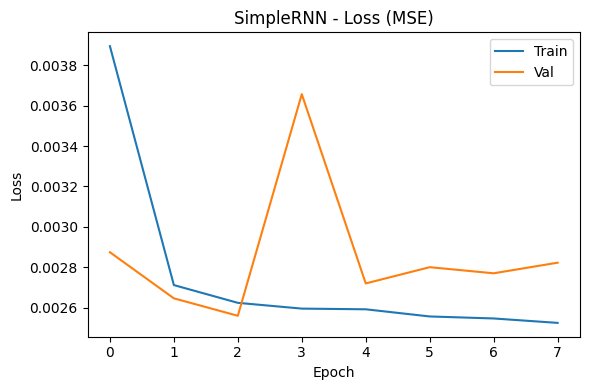

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.plot(history_rnn.history['loss'], label='Train')
plt.plot(history_rnn.history['val_loss'], label='Val')
plt.title('SimpleRNN - Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluate the SimpleRNN model on Test set

In [10]:
y_pred_scaled = model_rnn.predict(X_test)
y_pred_real   = scaler_y.inverse_transform(y_pred_scaled)
y_true_real   = scaler_y.inverse_transform(y_test.reshape(-1, 1))

shift = abs(scaler_y.data_min_[0]) + 1.0
rmsle_rnn = rmsle(y_true_real + shift, y_pred_real + shift).numpy()
print("SimpleRNN Evaluation on Test Set:")
print(f"RMSLE: {rmsle_rnn:.4f}")

1965/1965 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step
SimpleRNN Evaluation on Test Set:
RMSLE: 0.0914


# Create LSTM model with window size 72, adam optimizer, mse loss and rmsle metric

In [11]:
# LSTM - window size 72
model_lstm = Sequential([
    LSTM(64, input_shape=(window_size, X_train.shape[2])),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse', metrics=[rmsle])
model_lstm.summary()

/home/jagfoljersolen/APPROF/deep-learning-cnn-rnn-isep/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,777 (77.25 KB)

 Trainable params: 19,777 (77.25 KB)

 Non-trainable params: 0 (0.00 B)

# Train LSTM model with 10 epochs and batch 256

In [12]:
history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=30,
    batch_size=256,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30


W0000 00:00:1781185268.928402   10711 cpu_allocator_impl.cc:82] Allocation of 1016606592 exceeds 10% of free system memory.


1150/1150 ━━━━━━━━━━━━━━━━━━━━ 100s 85ms/step - loss: 0.0031 - rmsle: 0.0352 - val_loss: 0.0026 - val_rmsle: 0.0303
Epoch 2/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 98s 85ms/step - loss: 0.0025 - rmsle: 0.0330 - val_loss: 0.0033 - val_rmsle: 0.0339
Epoch 3/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 107s 93ms/step - loss: 0.0025 - rmsle: 0.0328 - val_loss: 0.0028 - val_rmsle: 0.0311
Epoch 4/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 105s 91ms/step - loss: 0.0024 - rmsle: 0.0325 - val_loss: 0.0026 - val_rmsle: 0.0296
Epoch 5/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 113s 98ms/step - loss: 0.0024 - rmsle: 0.0323 - val_loss: 0.0026 - val_rmsle: 0.0297


# Plot the results of the LSTM training performance

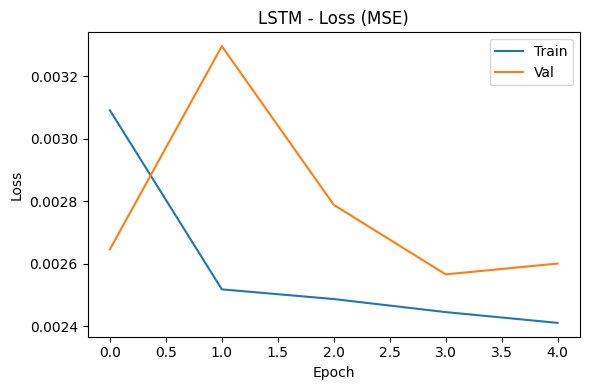

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(history_lstm.history['loss'], label='Train')
plt.plot(history_lstm.history['val_loss'], label='Val')
plt.title('LSTM - Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluate LSTM on the test set

In [14]:
y_pred_scaled = model_lstm.predict(X_test)
y_pred_real   = scaler_y.inverse_transform(y_pred_scaled)

rmsle_lstm = rmsle(y_true_real + shift, y_pred_real + shift).numpy()
print("LSTM Evaluation on Test Set:")
print(f"RMSLE: {rmsle_lstm:.4f}")

1965/1965 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step
LSTM Evaluation on Test Set:
RMSLE: 0.0944
